# ProtT5 Protein Embedding Analysis


In [86]:
import os
import gc
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from tqdm.auto import tqdm
from torch.utils.data import TensorDataset, DataLoader, Dataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, silhouette_score
from sklearn.metrics.pairwise import cosine_similarity

from transformers import T5Tokenizer, T5EncoderModel
from peft import LoraConfig, get_peft_model


warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("PyTorch:", torch.__version__)

PyTorch: 2.10.0+cu128


In [87]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Device:", device)

Device: cuda


In [88]:
# Change only this path if your dataset is stored elsewhere.
MODEL_NAME = "Rostlab/prot_t5_xl_half_uniref50-enc"
DATA_PATH = "/kaggle/input/datasets/rhulanim/protien-datasets/proteinas_20000_enriquecido.csv"
SEQUENCE_COLUMN = "Sequence"
TARGET_COLUMN = "class"
MAX_LENGTH = 512
PCA_COMPONENTS = 256

architecture_names = {(1, 10): "Mainly Alpha: Orthogonal Bundle", (1, 20): "Mainly Alpha: Up-down Bundle", (2, 30): "Mainly Beta: Roll", (2, 40): "Mainly Beta: Beta Barrel", (2, 60): "Mainly Beta: Sandwich", (3, 10): "Alpha Beta: Roll", (3, 20): "Alpha Beta: Alpha-Beta Barrel", (3, 30): "Alpha Beta: 2-Layer Sandwich", (3, 40): "Alpha Beta: 3-Layer(aba) Sandwich", (3, 90): "Alpha Beta: Alpha-Beta Complex"}

VALID_AA = set("ACDEFGHIKLMNPQRSTVWY")

def preprocess_sequence(seq):
    if pd.isna(seq):
        return ""
    return "".join(aa for aa in str(seq).upper() if aa in VALID_AA)

In [89]:
data = pd.read_csv(DATA_PATH, index_col=0)
data = data.dropna().copy()

data = data.rename(columns={"Sequência":"Sequence","Massa_Molecular":"Molecular_Weight","Ponto_Isoelétrico":"Isoelectric_Point","Hidrofobicidade":"Hydrophobicity","Carga_Total":"Total_Charge","Proporção_Polar":"Polar_Proportion","Proporção_Apolar":"Nonpolar_Proportion","Comprimento_Sequência":"Sequence_Length","Classe":"class"})
data.index.name = "Protein_ID"

valid_amino_acids = set("ACDEFGHIKLMNPQRSTVWY")

def clean_sequence(sequence):
    sequence = str(sequence).strip().upper()
    return "".join([aa for aa in sequence if aa in valid_amino_acids])

data["Sequence"] = data["Sequence"].map(clean_sequence)
data = data[data["Sequence"].str.len() > 0].copy()

balanced_data = data.groupby("class", group_keys=False).apply(lambda x: x.sample(n=min(6000,len(x)),random_state=SEED)).reset_index()
balanced_data = balanced_data.rename(columns={"index":"Protein_ID"})
balanced_data = balanced_data.set_index("Protein_ID")
balanced_data.index.name = "Protein_ID"

print("Dataset shape:", balanced_data.shape)
print("\nClass counts:")
print(balanced_data["class"].value_counts())
print("\nSequence length summary:")
print(balanced_data["Sequence"].str.len().describe())


Dataset shape: (30000, 9)

Class counts:
class
Enzima        6000
Estrutural    6000
Outras        6000
Receptora     6000
Transporte    6000
Name: count, dtype: int64

Sequence length summary:
count    30000.000000
mean       175.046367
std         72.281686
min         50.000000
25%        113.000000
50%        175.000000
75%        237.000000
max        300.000000
Name: Sequence, dtype: float64


In [90]:
# One split: 70% train, 15% validation, 15% test.
all_positions = np.arange(len(balanced_data))
all_labels = balanced_data["class"].to_numpy()

train_idx, test_idx = train_test_split(all_positions,test_size=0.20,random_state=SEED,stratify=all_labels)
train_idx, val_idx = train_test_split(train_idx,test_size=0.20,random_state=SEED,stratify=all_labels[train_idx])

assert len(set(train_idx) & set(val_idx)) == 0
assert len(set(train_idx) & set(test_idx)) == 0
assert len(set(val_idx) & set(test_idx)) == 0

train_df = data.iloc[train_idx].reset_index(drop=True)
val_df = data.iloc[val_idx].reset_index(drop=True)
test_df = data.iloc[test_idx].reset_index(drop=True)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 19200
Validation: 4800
Test: 6000


In [91]:
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(train_df[TARGET_COLUMN].astype(str))
y_val = label_encoder.transform(val_df[TARGET_COLUMN].astype(str))
y_test = label_encoder.transform(test_df[TARGET_COLUMN].astype(str))

class_names = label_encoder.classes_
num_classes = len(class_names)

print("Classes:", num_classes)
print(class_names)

Classes: 5
['Enzima' 'Estrutural' 'Outras' 'Receptora' 'Transporte']


In [92]:
tokenizer = T5Tokenizer.from_pretrained(MODEL_NAME, do_lower_case=False)
model = T5EncoderModel.from_pretrained(MODEL_NAME, torch_dtype=torch.float16 if device.type in {"cuda", "mps"} else torch.float32)
model = model.to(device)
model.eval()

print("Hidden size:", model.config.d_model)
print("Model device:", next(model.parameters()).device)

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Hidden size: 1024
Model device: cuda:0


In [93]:
@torch.inference_mode()
def embed_prott5(sequence, max_length=MAX_LENGTH):
    sequence = preprocess_sequence(sequence)
    sequence = " ".join(sequence)

    inputs = tokenizer(sequence, return_tensors="pt", truncation=True, max_length=max_length, padding=False)
    inputs = {key: value.to(device) for key, value in inputs.items()}

    outputs = model(**inputs)
    hidden = outputs.last_hidden_state
    mask = inputs["attention_mask"].bool()

    # Exclude EOS so pooling represents amino-acid residues only.
    if tokenizer.eos_token_id is not None:
        mask = mask & (inputs["input_ids"] != tokenizer.eos_token_id)

    mask = mask.unsqueeze(-1)
    pooled = (hidden * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1)
    return pooled.squeeze(0).float().cpu().numpy()

example_embedding = embed_prott5(train_df[SEQUENCE_COLUMN].iloc[0])
print("Embedding shape:", example_embedding.shape)

Embedding shape: (1024,)


In [94]:
raw_lengths = data[SEQUENCE_COLUMN].str.len()
print("Maximum sequence length:", raw_lengths.max())
print("Sequences longer than 512:", int((raw_lengths > MAX_LENGTH).sum()))
print("Percentage truncated:", round((raw_lengths > MAX_LENGTH).mean() * 100, 2), "%")

Maximum sequence length: 300
Sequences longer than 512: 0
Percentage truncated: 0.0 %


In [96]:
# GENERATE MASTER ProtT5 EMBEDDINGS

all_sequences = balanced_data[SEQUENCE_COLUMN].to_numpy()

master_embeddings = [embed_prott5(seq) for seq in tqdm(all_sequences, desc="ProtT5 embeddings")]
master_embeddings = np.asarray(master_embeddings, dtype=np.float32)

assert master_embeddings.shape == (len(balanced_data), model.config.d_model)

np.save("prott5_embeddings_float32.npy", master_embeddings)

# Create train/validation/test matrices from the same master embedding matrix
X_train = master_embeddings[train_idx]
X_val = master_embeddings[val_idx]
X_test = master_embeddings[test_idx]

print("Master:", master_embeddings.shape)
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

ProtT5 embeddings:   0%|          | 0/30000 [00:00<?, ?it/s]

Master: (30000, 1024)
Train: (19200, 1024)
Validation: (4800, 1024)
Test: (6000, 1024)


## Intrinsic embedding analysis

These checks describe the geometry of ProtT5 before supervised classification.

Mean norm: 1.7041585
Std norm: 0.22419229


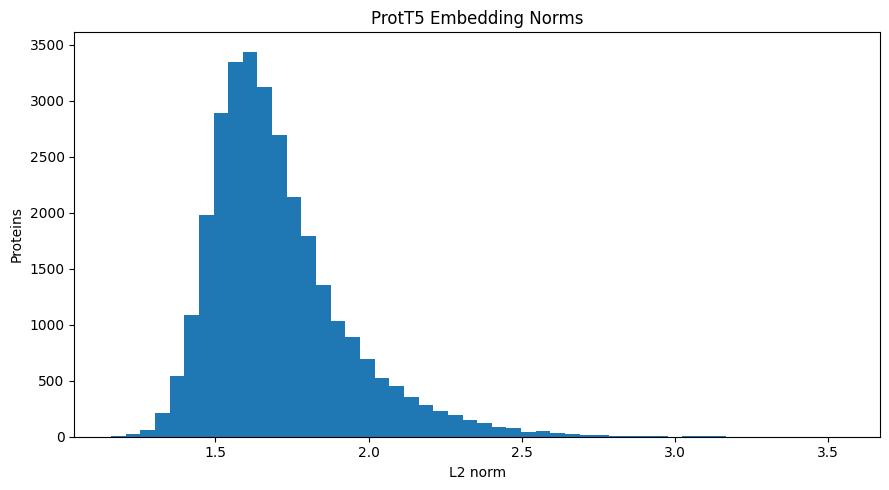

In [97]:
embedding_norms = np.linalg.norm(master_embeddings, axis=1)
print("Mean norm:", embedding_norms.mean())
print("Std norm:", embedding_norms.std())

plt.figure(figsize=(9, 5))
plt.hist(embedding_norms, bins=50)
plt.xlabel("L2 norm")
plt.ylabel("Proteins")
plt.title("ProtT5 Embedding Norms")
plt.tight_layout()
plt.show()

Near-zero variance dimensions: 0


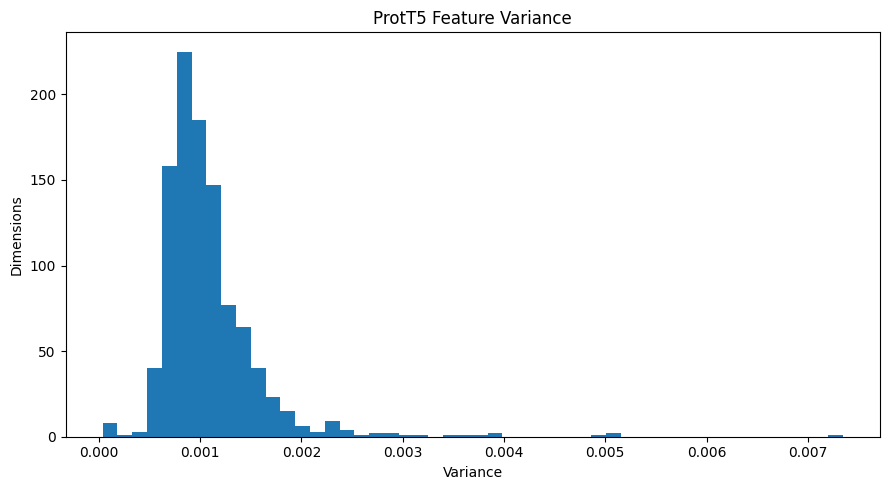

In [98]:
feature_variance = np.var(X_train, axis=0)
print("Near-zero variance dimensions:", int((feature_variance < 1e-8).sum()))

plt.figure(figsize=(9, 5))
plt.hist(feature_variance, bins=50)
plt.xlabel("Variance")
plt.ylabel("Dimensions")
plt.title("ProtT5 Feature Variance")
plt.tight_layout()
plt.show()

Explained variance: 0.9283


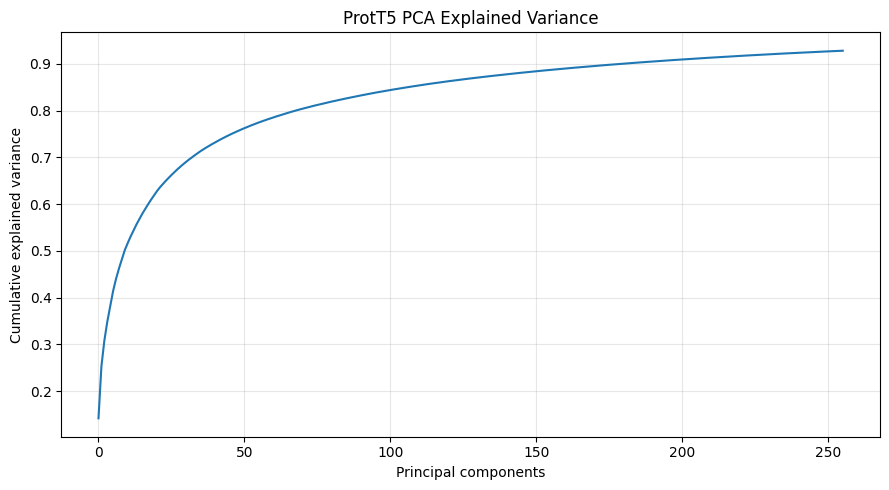

In [99]:
pca = PCA(n_components=PCA_COMPONENTS, random_state=SEED)
pca.fit(X_train)

X_train_pca = pca.transform(X_train).astype(np.float32)
X_val_pca = pca.transform(X_val).astype(np.float32)
X_test_pca = pca.transform(X_test).astype(np.float32)

print("Explained variance:", round(pca.explained_variance_ratio_.sum(), 4))

plt.figure(figsize=(9, 5))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Principal components")
plt.ylabel("Cumulative explained variance")
plt.title("ProtT5 PCA Explained Variance")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

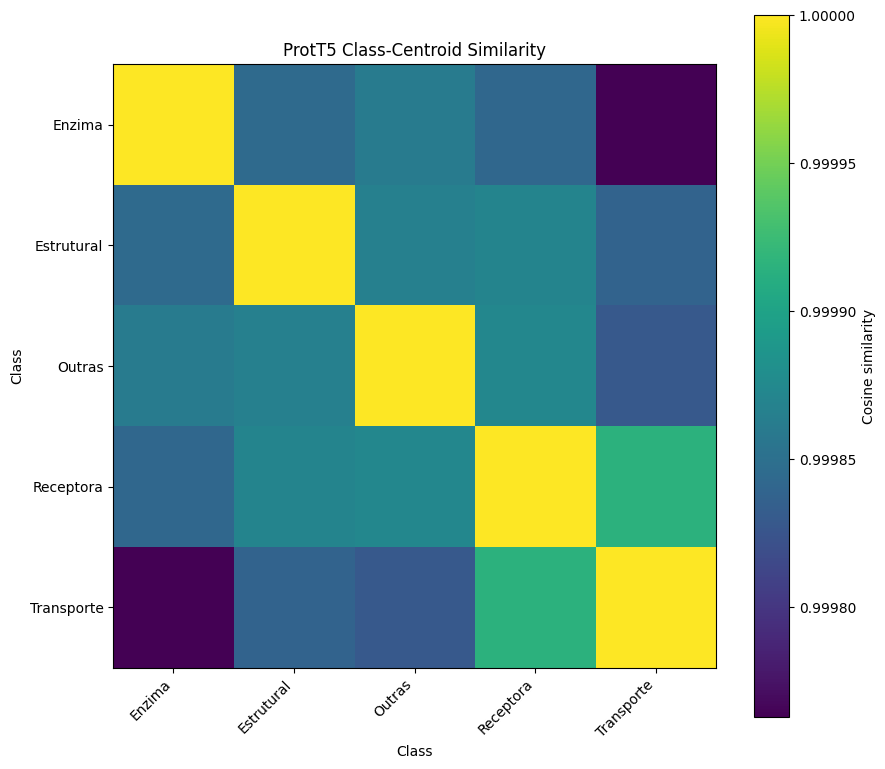

In [100]:
centroids = np.vstack([X_train[y_train == i].mean(axis=0) for i in range(num_classes)])
centroid_similarity = cosine_similarity(centroids)

plt.figure(figsize=(9, 8))
plt.imshow(centroid_similarity)
plt.colorbar(label="Cosine similarity")
plt.xticks(range(num_classes), class_names, rotation=45, ha="right")
plt.yticks(range(num_classes), class_names)
plt.xlabel("Class")
plt.ylabel("Class")
plt.title("ProtT5 Class-Centroid Similarity")
plt.tight_layout()
plt.show()

In [101]:
kmeans = KMeans(n_clusters=num_classes, random_state=SEED, n_init=10)
clusters = kmeans.fit_predict(X_train_pca)
print("Silhouette score:", round(silhouette_score(X_train_pca, clusters), 4))

Silhouette score: 0.0678


## Supervised baselines

PCA is fitted only on training data. Validation data is used for model selection; the test set is held out until the final comparison.

In [102]:
logreg_1024 = LogisticRegression(max_iter=1000, random_state=SEED)
logreg_1024.fit(X_train, y_train)
val_pred_1024 = logreg_1024.predict(X_val)
test_pred_1024 = logreg_1024.predict(X_test)

logreg_pca = LogisticRegression(max_iter=1000, random_state=SEED)
logreg_pca.fit(X_train_pca, y_train)
val_pred_pca = logreg_pca.predict(X_val_pca)
test_pred_pca = logreg_pca.predict(X_test_pca)

print("ProtT5-1024 validation accuracy:", round(accuracy_score(y_val, val_pred_1024), 4))
print("ProtT5 + PCA-256 validation accuracy:", round(accuracy_score(y_val, val_pred_pca), 4))

ProtT5-1024 validation accuracy: 0.2052
ProtT5 + PCA-256 validation accuracy: 0.2046


In [103]:
class LearnedProjectionClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_classes, dropout=0.2):
        super().__init__()
        self.projection = nn.Sequential(nn.Linear(input_dim, hidden_dim), nn.LayerNorm(hidden_dim), nn.GELU(), nn.Dropout(dropout), nn.Linear(hidden_dim, output_dim))
        self.classifier = nn.Linear(output_dim, num_classes)

    def forward(self, x):
        z = self.projection(x)
        return self.classifier(z), z

X_train_tensor = torch.from_numpy(X_train).float()
X_val_tensor = torch.from_numpy(X_val).float()
X_test_tensor = torch.from_numpy(X_test).float()
y_train_tensor = torch.from_numpy(y_train).long()
y_val_tensor = torch.from_numpy(y_val).long()
y_test_tensor = torch.from_numpy(y_test).long()

train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=128, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_tensor, y_val_tensor), batch_size=256, shuffle=False)

projection_model = LearnedProjectionClassifier(X_train.shape[1], 512, PCA_COMPONENTS, num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(projection_model.parameters(), lr=1e-3, weight_decay=1e-4)

EPOCHS = 100
PATIENCE = 10
history = {"train_loss": [], "val_loss": [], "train_accuracy": [], "val_accuracy": []}
best_val_loss = np.inf
best_state = None
patience_counter = 0

In [104]:
for epoch in range(EPOCHS):
    projection_model.train()
    train_loss_sum = 0.0
    train_correct = 0
    train_total = 0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        optimizer.zero_grad()
        logits, _ = projection_model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        train_loss_sum += loss.item() * y_batch.size(0)
        train_correct += (logits.argmax(1) == y_batch).sum().item()
        train_total += y_batch.size(0)

    train_loss = train_loss_sum / train_total
    train_accuracy = train_correct / train_total

    projection_model.eval()
    val_loss_sum = 0.0
    val_correct = 0
    val_total = 0

    with torch.inference_mode():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            logits, _ = projection_model(X_batch)
            loss = criterion(logits, y_batch)
            val_loss_sum += loss.item() * y_batch.size(0)
            val_correct += (logits.argmax(1) == y_batch).sum().item()
            val_total += y_batch.size(0)

    val_loss = val_loss_sum / val_total
    val_accuracy = val_correct / val_total
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_accuracy"].append(train_accuracy)
    history["val_accuracy"].append(val_accuracy)

    print(f"Epoch {epoch + 1:03d} | Train Loss: {train_loss:.4f} | Train Acc: {train_accuracy:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_accuracy:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {k: v.detach().cpu().clone() for k, v in projection_model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= PATIENCE:
        print("Early stopping.")
        break

projection_model.load_state_dict(best_state)
projection_model = projection_model.to(device)
print("Best validation loss:", round(best_val_loss, 4))

Epoch 001 | Train Loss: 1.6323 | Train Acc: 0.1993 | Val Loss: 1.6231 | Val Acc: 0.2046
Epoch 002 | Train Loss: 1.6131 | Train Acc: 0.2042 | Val Loss: 1.6141 | Val Acc: 0.2031
Epoch 003 | Train Loss: 1.6107 | Train Acc: 0.2090 | Val Loss: 1.6090 | Val Acc: 0.2008
Epoch 004 | Train Loss: 1.6082 | Train Acc: 0.2133 | Val Loss: 1.6126 | Val Acc: 0.1981
Epoch 005 | Train Loss: 1.6082 | Train Acc: 0.2171 | Val Loss: 1.6118 | Val Acc: 0.2100
Epoch 006 | Train Loss: 1.6074 | Train Acc: 0.2156 | Val Loss: 1.6114 | Val Acc: 0.2065
Epoch 007 | Train Loss: 1.6057 | Train Acc: 0.2268 | Val Loss: 1.6128 | Val Acc: 0.2060
Epoch 008 | Train Loss: 1.6036 | Train Acc: 0.2272 | Val Loss: 1.6153 | Val Acc: 0.2046
Epoch 009 | Train Loss: 1.6019 | Train Acc: 0.2336 | Val Loss: 1.6161 | Val Acc: 0.1979
Epoch 010 | Train Loss: 1.5997 | Train Acc: 0.2348 | Val Loss: 1.6168 | Val Acc: 0.2067
Epoch 011 | Train Loss: 1.5972 | Train Acc: 0.2409 | Val Loss: 1.6173 | Val Acc: 0.2006
Epoch 012 | Train Loss: 1.5945 |

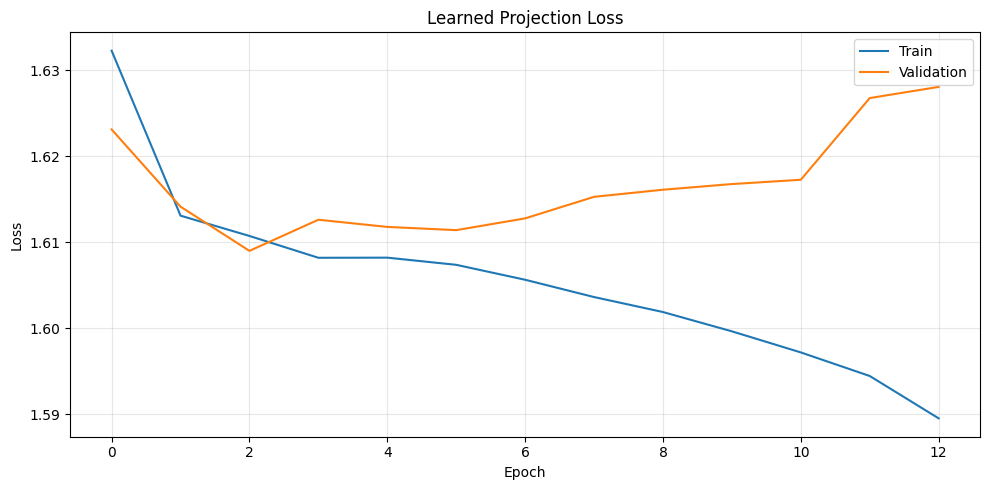

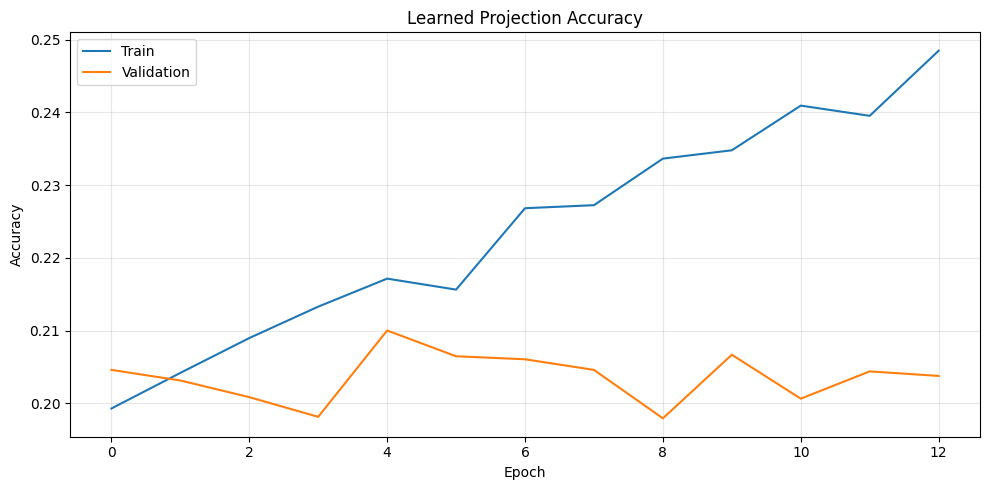

In [105]:
plt.figure(figsize=(10, 5))
plt.plot(history["train_loss"], label="Train")
plt.plot(history["val_loss"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Learned Projection Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history["train_accuracy"], label="Train")
plt.plot(history["val_accuracy"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Learned Projection Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [106]:
projection_model.eval()
with torch.inference_mode():
    test_logits, test_z = projection_model(X_test_tensor.to(device))
learned_test_pred = test_logits.argmax(1).cpu().numpy()
learned_test_embedding = test_z.cpu().numpy()

def metric_row(y_true, y_pred, name):
    return {"Model": name, "Accuracy": accuracy_score(y_true, y_pred), "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred), "Macro Precision": precision_score(y_true, y_pred, average="macro", zero_division=0), "Macro Recall": recall_score(y_true, y_pred, average="macro", zero_division=0), "Macro F1": f1_score(y_true, y_pred, average="macro", zero_division=0), "Weighted F1": f1_score(y_true, y_pred, average="weighted", zero_division=0)}

results = pd.DataFrame([metric_row(y_test, test_pred_1024, "ProtT5-1024"), metric_row(y_test, test_pred_pca, "ProtT5 + PCA-256"), metric_row(y_test, learned_test_pred, "ProtT5 + Learned-256")]).set_index("Model")
print(results.round(4))

                      Accuracy  Balanced Accuracy  Macro Precision  \
Model                                                                
ProtT5-1024             0.1963             0.1965           0.1956   
ProtT5 + PCA-256        0.1923             0.1925           0.1909   
ProtT5 + Learned-256    0.1972             0.1975           0.1477   

                      Macro Recall  Macro F1  Weighted F1  
Model                                                      
ProtT5-1024                 0.1965    0.1955       0.1953  
ProtT5 + PCA-256            0.1925    0.1909       0.1907  
ProtT5 + Learned-256        0.1975    0.1486       0.1485  



Classification report — best model:
Best model: ProtT5-1024
              precision    recall  f1-score   support

      Enzima       0.21      0.21      0.21      1183
  Estrutural       0.19      0.22      0.20      1204
      Outras       0.20      0.21      0.20      1220
   Receptora       0.17      0.14      0.15      1218
  Transporte       0.20      0.21      0.21      1175

    accuracy                           0.20      6000
   macro avg       0.20      0.20      0.20      6000
weighted avg       0.20      0.20      0.20      6000



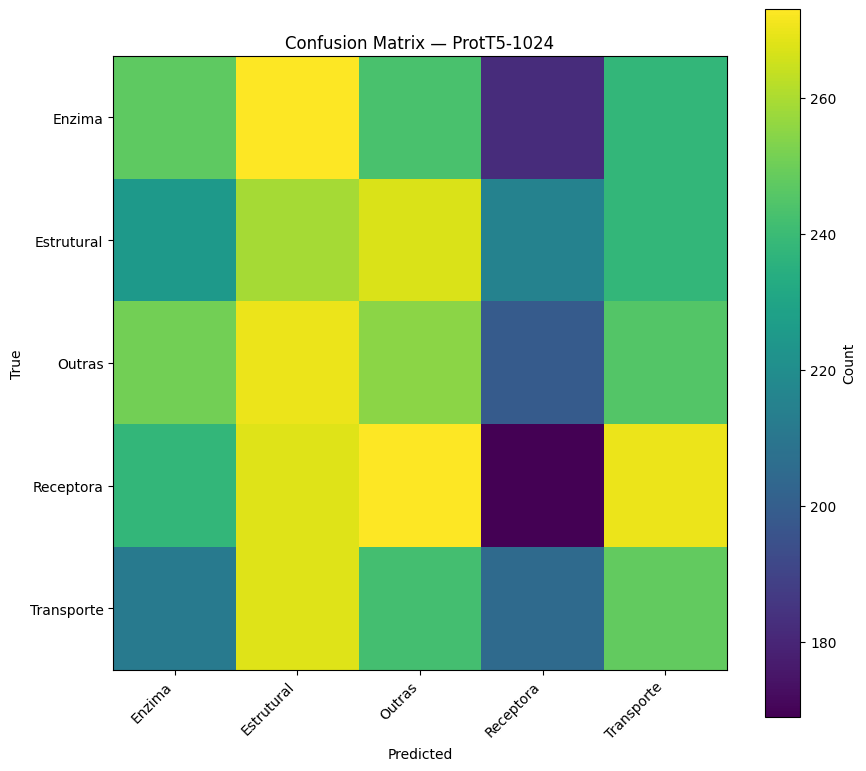

In [107]:
print("\nClassification report — best model:")
best_model = results["Macro F1"].idxmax()
prediction_map = {"ProtT5-1024": test_pred_1024, "ProtT5 + PCA-256": test_pred_pca, "ProtT5 + Learned-256": learned_test_pred}
best_pred = prediction_map[best_model]
print("Best model:", best_model)
print(classification_report(y_test, best_pred, target_names=class_names, zero_division=0))

cm = confusion_matrix(y_test, best_pred)
plt.figure(figsize=(9, 8))
plt.imshow(cm)
plt.colorbar(label="Count")
plt.xticks(range(num_classes), class_names, rotation=45, ha="right")
plt.yticks(range(num_classes), class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"Confusion Matrix — {best_model}")
plt.tight_layout()
plt.show()

## Optional ProtT5 + LoRA fine-tuning

This section is disabled by default. It is intentionally conservative for MPS memory. It uses batch size 1, gradient accumulation, gradient checkpointing, `use_cache=False`, and validation-loss early stopping. The test set is evaluated only after training is complete.

If the full ProtT5 model still exceeds available MPS memory, keep `RUN_LORA = False` and use the frozen ProtT5 embedding pipeline above.

In [108]:
RUN_LORA = False
LORA_BATCH_SIZE = 1
LORA_GRAD_ACCUMULATION = 8
LORA_EPOCHS = 10
LORA_PATIENCE = 3
LORA_MAX_LENGTH = 512
LORA_LR = 2e-4
print("RUN_LORA:", RUN_LORA)

RUN_LORA: False


In [109]:
if RUN_LORA:
    class ProteinDataset(Dataset):
        def __init__(self, sequences, labels, tokenizer, max_length=512):
            self.sequences = list(sequences)
            self.labels = np.asarray(labels)
            self.tokenizer = tokenizer
            self.max_length = max_length

        def __len__(self):
            return len(self.sequences)

        def __getitem__(self, idx):
            sequence = " ".join(preprocess_sequence(self.sequences[idx]))
            encoded = self.tokenizer(sequence, padding="max_length", truncation=True, max_length=self.max_length, return_tensors="pt")
            return {"input_ids": encoded["input_ids"].squeeze(0), "attention_mask": encoded["attention_mask"].squeeze(0), "labels": torch.tensor(self.labels[idx], dtype=torch.long)}

    train_dataset = ProteinDataset(train_df[SEQUENCE_COLUMN], y_train, tokenizer, LORA_MAX_LENGTH)
    val_dataset = ProteinDataset(val_df[SEQUENCE_COLUMN], y_val, tokenizer, LORA_MAX_LENGTH)
    test_dataset = ProteinDataset(test_df[SEQUENCE_COLUMN], y_test, tokenizer, LORA_MAX_LENGTH)
    train_loader_lora = DataLoader(train_dataset, batch_size=LORA_BATCH_SIZE, shuffle=True)
    val_loader_lora = DataLoader(val_dataset, batch_size=LORA_BATCH_SIZE, shuffle=False)
    test_loader_lora = DataLoader(test_dataset, batch_size=LORA_BATCH_SIZE, shuffle=False)

    lora_encoder = T5EncoderModel.from_pretrained(MODEL_NAME, torch_dtype=torch.float16 if device.type in {"cuda", "mps"} else torch.float32).to(device)
    lora_encoder.config.use_cache = False
    lora_encoder.gradient_checkpointing_enable()

    lora_config = LoraConfig(r=8, lora_alpha=16, target_modules=["q", "v"], lora_dropout=0.10, bias="none", task_type="FEATURE_EXTRACTION")
    lora_encoder = get_peft_model(lora_encoder, lora_config)

    class ProtT5LoRAClassifier(nn.Module):
        def __init__(self, encoder, hidden_dim, num_classes):
            super().__init__()
            self.encoder = encoder
            self.classifier = nn.Sequential(nn.Linear(hidden_dim, 512), nn.LayerNorm(512), nn.GELU(), nn.Dropout(0.30), nn.Linear(512, num_classes))

        def forward(self, input_ids, attention_mask):
            outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
            hidden = outputs.last_hidden_state
            mask = attention_mask.bool()
            if tokenizer.eos_token_id is not None:
                mask = mask & (input_ids != tokenizer.eos_token_id)
            mask = mask.unsqueeze(-1)
            pooled = (hidden * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1)
            return self.classifier(pooled)

    lora_model = ProtT5LoRAClassifier(lora_encoder, lora_encoder.config.d_model, num_classes).to(device)
    trainable_params = sum(p.numel() for p in lora_model.parameters() if p.requires_grad)
    total_params = sum(p.numel() for p in lora_model.parameters())
    print(f"Trainable: {trainable_params:,}")
    print(f"Total: {total_params:,}")
    print(f"Trainable %: {100 * trainable_params / total_params:.3f}%")

In [110]:
if RUN_LORA:
    criterion_lora = nn.CrossEntropyLoss()
    optimizer_lora = torch.optim.AdamW(filter(lambda p: p.requires_grad, lora_model.parameters()), lr=LORA_LR, weight_decay=1e-4)
    lora_history = {"train_loss": [], "val_loss": [], "train_accuracy": [], "val_accuracy": []}
    best_val_loss_lora = np.inf
    best_state_lora = None
    patience_counter_lora = 0

    for epoch in range(LORA_EPOCHS):
        lora_model.train()
        optimizer_lora.zero_grad()
        train_loss_sum = 0.0
        train_correct = 0
        train_total = 0

        for step, batch in enumerate(tqdm(train_loader_lora, desc=f"LoRA Epoch {epoch + 1}/{LORA_EPOCHS}")):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels_batch = batch["labels"].to(device)
            logits = lora_model(input_ids, attention_mask)
            loss = criterion_lora(logits, labels_batch) / LORA_GRAD_ACCUMULATION
            loss.backward()
            train_loss_sum += loss.item() * LORA_GRAD_ACCUMULATION * labels_batch.size(0)
            train_correct += (logits.argmax(1) == labels_batch).sum().item()
            train_total += labels_batch.size(0)

            if (step + 1) % LORA_GRAD_ACCUMULATION == 0 or (step + 1) == len(train_loader_lora):
                optimizer_lora.step()
                optimizer_lora.zero_grad()

        train_loss = train_loss_sum / train_total
        train_accuracy = train_correct / train_total

        lora_model.eval()
        val_loss_sum = 0.0
        val_correct = 0
        val_total = 0
        with torch.inference_mode():
            for batch in val_loader_lora:
                input_ids = batch["input_ids"].to(device)
                attention_mask = batch["attention_mask"].to(device)
                labels_batch = batch["labels"].to(device)
                logits = lora_model(input_ids, attention_mask)
                loss = criterion_lora(logits, labels_batch)
                val_loss_sum += loss.item() * labels_batch.size(0)
                val_correct += (logits.argmax(1) == labels_batch).sum().item()
                val_total += labels_batch.size(0)

        val_loss = val_loss_sum / val_total
        val_accuracy = val_correct / val_total
        lora_history["train_loss"].append(train_loss)
        lora_history["val_loss"].append(val_loss)
        lora_history["train_accuracy"].append(train_accuracy)
        lora_history["val_accuracy"].append(val_accuracy)
        print(f"Epoch {epoch + 1:03d} | Train Loss: {train_loss:.4f} | Train Acc: {train_accuracy:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_accuracy:.4f}")

        if val_loss < best_val_loss_lora:
            best_val_loss_lora = val_loss
            best_state_lora = {k: v.detach().cpu().clone() for k, v in lora_model.state_dict().items()}
            patience_counter_lora = 0
        else:
            patience_counter_lora += 1

        if patience_counter_lora >= LORA_PATIENCE:
            print("LoRA early stopping.")
            break

    lora_model.load_state_dict(best_state_lora)
    lora_model = lora_model.to(device)
    print("Best LoRA validation loss:", round(best_val_loss_lora, 4))

In [111]:
if RUN_LORA:
    lora_model.eval()
    lora_predictions = []
    lora_true = []
    with torch.inference_mode():
        for batch in tqdm(test_loader_lora, desc="LoRA test inference"):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            logits = lora_model(input_ids, attention_mask)
            lora_predictions.extend(logits.argmax(1).cpu().numpy())
            lora_true.extend(batch["labels"].numpy())

    lora_predictions = np.asarray(lora_predictions)
    lora_true = np.asarray(lora_true)
    lora_results = pd.DataFrame([metric_row(lora_true, lora_predictions, "ProtT5 + LoRA")]).set_index("Model")
    print(lora_results.round(4))
    print(classification_report(lora_true, lora_predictions, target_names=class_names, zero_division=0))

## Interpretation

- **ProtT5-1024:** tests the original representation without dimensionality reduction.
- **PCA-256:** tests whether most useful information can be retained in a compact unsupervised representation.
- **Learned-256:** learns a supervised compact representation specifically for the target classes.
- **LoRA:** changes ProtT5 itself through parameter-efficient fine-tuning and should be treated as a separate experiment.

The most defensible final model is selected using validation performance, then reported once on the held-out test set.